###IMPORTING NECESSARY LIBRARIES

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm 
import matplotlib.pyplot as plt
import numpy as np

###LOADING DATA

In [2]:
INPUT_SIZE = 1024  #32 * 32
NUM_EPOCHS = 50
NUM_CLASSES = 10
DEVICE = torch.device("cuda:0" if torch.cuda.is_available else "cpu")
INPUT_CHANNELS = 3
LEARNING_RATE = 0.001
BATCH_SIZE = 64
INPUT_DIM = INPUT_SIZE * INPUT_CHANNELS

# output of torchvision datasets are PIL Images
# Transforming them to tensors 
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


###MODELS

In [3]:
class NetA(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()

    self.fc = nn.Linear(input_size, output_size)

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.fc(x)

    return x

class NetB(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()

    self.fc1 = nn.Linear(input_size, 300)
    self.fc2 = nn.Linear(300, output_size)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)

    return x

class NetC(nn.Module):
  def __init__(self, in_channels, num_classes):
    super().__init__()

    self.conv = nn.Conv2d(in_channels=in_channels,
                          out_channels=25, 
                          kernel_size=(5,5))
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(kernel_size=2, stride = 2)
    self.fc = nn.Linear(25 * 14 * 14, num_classes)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    x = x.view(x.size(0), -1)
    x = self.fc(x)

    return x

###PLOTTING FUNCTION

In [4]:
def plot_history(train_history, val_history):

  plt.plot(train_history)
  plt.plot(val_history)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Train','Validation'])
  plt.title(f' MODEL: {net_name}')
    
  plt.show()

###TRAIN AND VALIDATION LOOP

In [5]:
def train_val(model, trainloader, testloader, num_epochs, criterion, optimizer, device):
  
  model.to(device)
  train_losses=[]
  train_accu=[]
  eval_losses=[]
  eval_accu=[]

  for epoch in (range(num_epochs)):
    train = True
    if(train):
      
      model.train()
    
      running_loss = 0
      correct = 0
      total = 0
    
      for data in (trainloader):
        
        inputs, labels = data[0].to(device), data[1].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
    
        running_loss += loss.item()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
          
      train_loss = running_loss/len(trainloader)
      train_accuracy = 100. * correct/total
      
      train_accu.append(train_accuracy)
      train_losses.append(train_loss)
    
    train = False

    if(not train):
        model.eval()
      
        running_loss=0
        correct=0
        total=0
      
        with torch.no_grad():
          for data in (testloader):
            images,labels = data[0].to(device), data[1].to(device)
            
            outputs = model(images)
      
            loss = criterion(outputs,labels)
            running_loss += loss.item()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        test_loss=running_loss/len(testloader)
        test_accuracy=100.*correct/total
      
        eval_losses.append(test_loss)
        eval_accu.append(test_accuracy)
      
  print('Train Loss: %.3f | Train Accuracy: %.3f'%(train_loss,train_accuracy))
  print('Test Loss: %.3f | Test Accuracy: %.3f'%(test_loss,test_accuracy))
  
  return train_accu, eval_accu

###FINAL OUTPUT

==== Training NetA ====
Train Loss: 1.615 | Train Accuracy: 45.208
Test Loss: 1.745 | Test Accuracy: 40.250


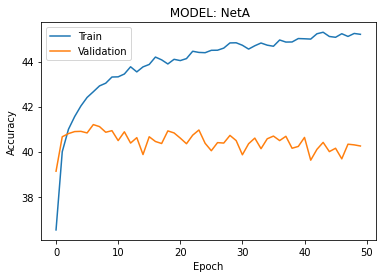

==== Training NetB ====
Train Loss: 0.642 | Train Accuracy: 80.046
Test Loss: 1.419 | Test Accuracy: 53.920


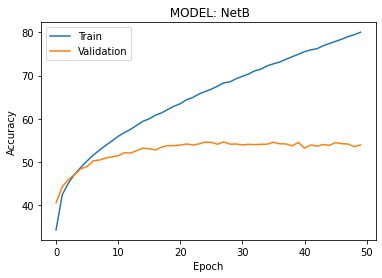

==== Training NetC ====


/usr/local/lib/python3.7/dist-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /pytorch/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Train Loss: 0.709 | Train Accuracy: 75.792
Test Loss: 1.069 | Test Accuracy: 65.010


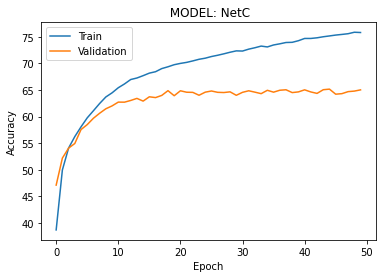

In [6]:
nets = [NetA(input_size=INPUT_DIM, output_size=NUM_CLASSES),
        NetB(input_size=INPUT_DIM, output_size=NUM_CLASSES),
        NetC(in_channels=INPUT_CHANNELS, num_classes=NUM_CLASSES)]

for net in nets:
  net_name = type(net).__name__
  print(f'==== Training {net_name} ====')
  CRITERION = nn.CrossEntropyLoss()
  OPTIMIZER = optim.SGD(net.parameters(), lr=LEARNING_RATE, momentum=0.9)
  net_name = type(net).__name__
  train_history, val_history = train_val(net, 
                                          trainloader=trainloader, 
                                          testloader=testloader,
                                          num_epochs=NUM_EPOCHS,
                                          criterion=CRITERION,
                                          optimizer=OPTIMIZER,
                                          device=DEVICE)
      
  plot_history(train_history, val_history)
